# Extrinsic marginalization with precession and higher modes

This tutorial illustrates details about the `cogwheel` objects that take care of computing a likelihood marginalized over extrinsic parameters.

If you just want to run parameter estimation you don't need to deal with these, see the [`factorized_phm.ipynb`](https://github.com/jroulet/cogwheel/blob/main/tutorials/factorized_phm.ipynb) tutorial instead.

The relevant subpackage is `cogwheel.likelihood.marginalization`.

Reference: https://arxiv.org/abs/2404.02435

In [1]:
# Ensure only one CPU is used:
import os
os.environ["OMP_NUM_THREADS"] = "1"

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cogwheel import data, posterior
from cogwheel.likelihood.marginalization.coherent_score_lensing import CoherentScoreLensing

%matplotlib widget

In [2]:
eventname = 'GW190412'

In [3]:
# Create and save `EventData` file
if not data.EventData.get_filename(eventname).exists():
    filenames, detector_names, tgps = data.download_timeseries(eventname)
    event_data = data.EventData.from_timeseries(
        filenames, eventname, detector_names, tgps, t_before=16., fmax=1024.)
    event_data.to_npz()

In [4]:
# Automatically instantiate a Posterior object.
post = posterior.Posterior.from_event(
    eventname,
    data.EVENTS_METADATA['mchirp'][eventname],
    'IMRPhenomXPHM',
    'CartesianIntrinsicIASPrior')

Searching incoherent solution for GW190412
Set intrinsic parameters, lnL = 167.17977523678252
Set time, lnL(L) = 121.77850922898354
Set sky location, lnL = 165.34177346895825
Set phase and distance, lnL = 165.34177346895825
Set mchirp_range = (np.float64(12.678974868982504), np.float64(19.709664363865798))


In [5]:
post.likelihood.coherent_score.get_init_dict()

{'beta_temperature': array([0.7924829 , 1.        , 0.30538555]),
 'min_n_effective': 50,
 'log2n_qmc': 11,
 'learning_rate': 0.01,
 'n_qmc_sequences': 128,
 'm_arr': array([2, 1, 3, 4]),
 'sky_dict': <cogwheel.likelihood.marginalization.skydict.SkyDictionary at 0x7f003dfb3a50>,
 'seed': 0,
 'lookup_table': LookupTable(d_luminosity_prior_name='euclidean', d_luminosity_max=15000.0, shape=(256, 128)),
 'nphi': 128,
 'max_log2n_qmc': 15}

In [6]:
# instantiate a CoherentScoreLensing object
coherent_score = CoherentScoreLensing(**post.likelihood.coherent_score.get_init_dict())

In [7]:
lensing_likelihood = post.likelihood.reinstantiate(coherent_score=coherent_score)

In [8]:
dir(lensing_likelihood)

['__abstractmethods__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_asd_drift',
 '_basis_splines',
 '_coefficients',
 '_compute_d_h',
 '_compute_h_h',
 '_create_coherent_score',
 '_d_h_weights',
 '_fbin',
 '_get_dh_hh_timeshift',
 '_get_h_f',
 '_get_linearfree_hplus_hcross_dt',
 '_get_summary_weights',
 '_get_whitened_td',
 '_h2plus0_fbin',
 '_h_h_weights',
 '_matched_filter_timeseries',
 '_max_lnl_marginalized',
 '_par_dic_0',
 '_pn_phase_tol',
 '_polyfit_weights',
 '_ref_dic',
 '_safe_std',
 '_set_d_h_weights',
 '_set_h_h_weights',
 '_set_splines',
 '_set_summary',
 '_setup_data_figure',
 '_spline_degree',
 '_stall_r

## `MarginalizedExtrinsicLikelihood`

Takes care of computing matched-filtering time series `d_h` and covariances `h_h` that are the input to the marginalization.

In [9]:
# Since we used an "Intrinsic" prior, it figured out that we want a MarginalizedExtrinsicLikelihood:
# like = post.likelihood
like = lensing_likelihood
like.__class__

cogwheel.likelihood.marginalized_extrinsic.MarginalizedExtrinsicLikelihood

In [10]:
d_h, h_h, timeshift = like._get_dh_hh_timeshift(like.par_dic_0)

# We apply a small time shift to align the waveform to the relative binning reference
times = like._times - timeshift

In [11]:
d_h.shape  # modes, polarizations, times, detectors

(4, 2, 287, 3)

In [12]:
h_h.shape  # mode pairs, polarizations, polarizations', detectors

(10, 2, 2, 3)

In [13]:
times.shape

(287,)

## `CoherentScoreHM`
Computes the marginalized likelihood given the timeseries and covariances.

Generates extrinsic-parameter samples.

In [14]:
coherent_score = like.coherent_score
coherent_score.__class__

cogwheel.likelihood.marginalization.coherent_score_lensing.CoherentScoreLensing

In [15]:
coherent_score.min_n_effective  # Convergence criterion

50

In [16]:
2**coherent_score.log2n_qmc  # Samples per proposal

2048

In [17]:
# Compute the marginalized likelihood:
marg_info = coherent_score.get_marginalization_info(d_h, h_h, times)
marg_info.lnl_marginalized

np.float64(150.03808417955537)

In [18]:
marg_info.p_lensed

np.float64(0.7031322357325037)

In [19]:
# Generate extrinsic parameter samples
pd.DataFrame(coherent_score.gen_samples_from_marg_info(marg_info, num=10))

,d_luminosity,dec,lon,phi_ref,psi,t_geocenter,lnl_marginalized,lnl,h_h,n_effective,n_qmc,p_lensed
0,627.511664,0.634460,5.154469,0.638136,1.488478,0.082133,150.038084,181.328506,359.923082,66.82413,2048,0.703132
1,619.751455,0.609012,5.186458,0.392699,1.846067,0.081829,150.038084,179.124686,329.300949,66.82413,2048,0.703132
2,639.702980,0.623741,5.178091,0.147262,2.778395,0.081873,150.038084,179.786225,308.309481,66.82413,2048,0.703132
3,590.367023,0.636309,5.152695,0.294524,2.695784,0.082305,150.038084,178.895828,354.316686,66.82413,2048,0.703132
4,611.556790,0.628338,5.153141,0.687223,1.500279,0.082142,150.038084,182.489630,379.070355,66.82413,2048,0.703132
5,697.022707,0.625201,5.181267,0.785398,1.372607,0.081862,150.038084,178.389884,277.940676,66.82413,2048,0.703132
6,651.787040,0.637419,5.136805,0.441786,1.764636,0.082272,150.038084,181.071026,319.234740,66.82413,2048,0.703132
7,651.874519,0.610315,5.161665,0.539961,1.623016,0.082051,150.038084,180.251540,327.481942,66.82413,2048,0.703132
8,577.184771,0.641393,5.146323,0.736311,2.208377,0.082176,150.038084,180.835836,324.125724,66.82413,2048,0.703132
9,649.297813,0.638051,5.169555,0.736311,1.441057,0.082086,150.038084,182.182632,330.233468,66.82413,2048,0.703132


## `MarginalizationInfoLensing`
Contains data products associated with a single likelihood marginalization.

In [20]:
marg_info.__class__

cogwheel.likelihood.marginalization.coherent_score_lensing.MarginalizationInfoLensing

In [21]:
marg_info.lnl_marginalized  # Final answer

np.float64(150.03808417955537)

In [22]:
marg_info.n_effective  # Effective number of samples achieved

np.float64(66.82413003906905)

In [23]:
len(marg_info.proposals)  # The importance sampling integral required these many adaptations to converge

1

In [24]:
marg_info.proposals[0].shape  # detectors, upsampled times

# Note that times have been upsampled to match the resolution of the sky dictionary (see below)

_, upsampled_times = coherent_score.sky_dict.resample_timeseries(np.zeros_like(times), times)

Text(0, 0.5, 'Detector time of arrival proposal, $P_d^{(0)}(\\tau)$')

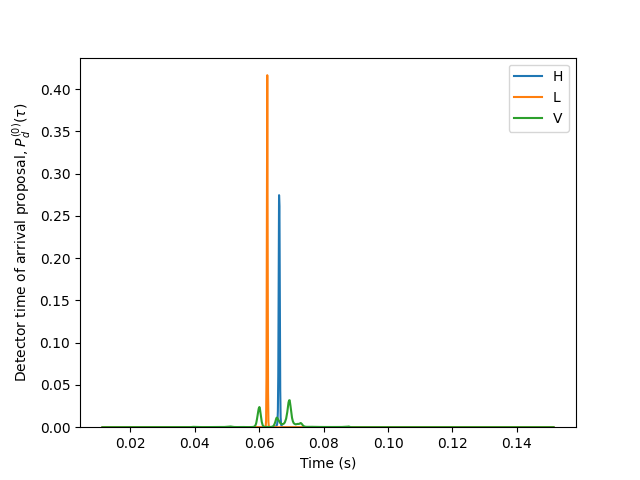

In [25]:
# Plot a proposal
j_proposal = 0
plt.figure()
plt.plot(upsampled_times, marg_info.proposals[j_proposal].T, label=coherent_score.sky_dict.detector_names)
plt.legend()
plt.ylim(0)
plt.xlabel('Time (s)')
plt.ylabel(rf'Detector time of arrival proposal, $P_d^{{({j_proposal})}}(\tau)$')

## `SkyDictionary`
Maps discrete time delays to arrival directions.

Computes prior of time delays.

In [26]:
sky_dict = coherent_score.sky_dict
sky_dict.__class__

cogwheel.likelihood.marginalization.skydict.SkyDictionary

In [27]:
pd.DataFrame(sky_dict.sky_samples)  # Quasi Monte Carlo sequence of isotropic samples in the sky

,lat,lon
0,0.427338,2.947314
1,-0.625559,5.041710
2,1.154146,0.852919
3,-0.085655,2.249183
4,0.165200,4.343578
...,...,...
999995,-0.178238,0.523974
999996,0.072768,4.014633
999997,-1.187123,6.109028
999998,0.609801,1.920238


In [28]:
sky_dict.f_sampling  # The time axis is discretized at this resolution (Hz) := 1/Delta

8192

In [29]:
sky_dict.detector_names

('H', 'L', 'V')

In [30]:
list(sky_dict.delays2inds_map.keys())[:10]  # Keys are (HL delay, HV delay) in units of Delta 

[(np.int64(74), np.int64(144)),
 (np.int64(-72), np.int64(46)),
 (np.int64(33), np.int64(-82)),
 (np.int64(68), np.int64(15)),
 (np.int64(-15), np.int64(184)),
 (np.int64(-59), np.int64(-115)),
 (np.int64(46), np.int64(170)),
 (np.int64(-81), np.int64(-88)),
 (np.int64(53), np.int64(-124)),
 (np.int64(12), np.int64(128))]

In [31]:
sky_dict.delays2inds_map[10, 20]  # Indices of samples with these time delays

[274629, 281026, 295365, 343234, 529858, 716482, 840898, 855237]

In [32]:
sky_dict.get_sky_inds_and_prior(delays=np.array(([10], [20])))  # Sky sample index, prior, and whether the delays requested are physical

(array([274629]), array([9.765625e-10]), array([ True]))

## `LookupTable`
Marginalizes the likelihood over distance.

In [33]:
coherent_score.lookup_table.__class__

cogwheel.likelihood.marginalization.lookup_table.LookupTable

In [34]:
coherent_score.lookup_table.d_luminosity_prior_name

'euclidean'

In [35]:
coherent_score.lookup_table.marginalized_params

{'d_luminosity'}

In [36]:
coherent_score.lookup_table.d_luminosity_max  # Mpc

15000.0

In [37]:
coherent_score.lookup_table.lnlike_marginalized(marg_info.d_h[0], marg_info.h_h[0])

/home/abbye.williams/venv/gwaves/lib/python3.11/site-packages/scipy/interpolate/_fitpack2.py:1089: ComplexWarning: Casting complex values to real discards the imaginary part
  z, ier = dfitpack.bispeu(tx, ty, c, kx, ky, x, y)


np.complex128(160.98271323969817-13.610418319702148j)